In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [20]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

df = pd.DataFrame({
    'Age': np.random.randint(22, 60, n),
    'MonthlyIncome': np.random.randint(20000, 150000, n),
    'YearsAtCompany': np.random.randint(0, 20, n),
    'JobSatisfaction': np.random.randint(1, 5, n),
    'WorkLifeBalance': np.random.randint(1, 5, n),
    'OverTime': np.random.choice(['Yes', 'No'], n),
    'Department': np.random.choice(['Sales', 'HR', 'IT'], n),
    'Attrition': np.random.choice([0, 1], n, p=[0.8, 0.2])
})

df.to_csv('employee_retention.csv', index=False)

print("CSV file created successfully!")

CSV file created successfully!


In [21]:
df = pd.read_csv("employee_retention.csv")

print(df.head())
print(df.info())

   Age  MonthlyIncome  YearsAtCompany  JobSatisfaction  WorkLifeBalance  \
0   50          22717               6                3                2   
1   36          79676               9                3                4   
2   29          47952              18                2                1   
3   42         106444              18                2                1   
4   40          62460              11                3                2   

  OverTime Department  Attrition  
0       No         IT          0  
1       No         IT          0  
2      Yes      Sales          0  
3       No         HR          0  
4       No         IT          1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              1000 non-null   int64 
 1   MonthlyIncome    1000 non-null   int64 
 2   YearsAtCompany   1000 non-null   int64 
 3   JobS

In [22]:
print(df.isnull().sum())

Age                0
MonthlyIncome      0
YearsAtCompany     0
JobSatisfaction    0
WorkLifeBalance    0
OverTime           0
Department         0
Attrition          0
dtype: int64


In [23]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [24]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred = model.predict(X_test)

In [28]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.83

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       172
           1       0.00      0.00      0.00        28

    accuracy                           0.83       200
   macro avg       0.43      0.48      0.45       200
weighted avg       0.74      0.83      0.78       200


Confusion Matrix:
[[166   6]
 [ 28   0]]


In [29]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

           Feature  Importance
1    MonthlyIncome    0.291747
0              Age    0.238142
2   YearsAtCompany    0.200451
3  JobSatisfaction    0.086042
4  WorkLifeBalance    0.078192
6       Department    0.069032
5         OverTime    0.036396


In [30]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.5485880398671096


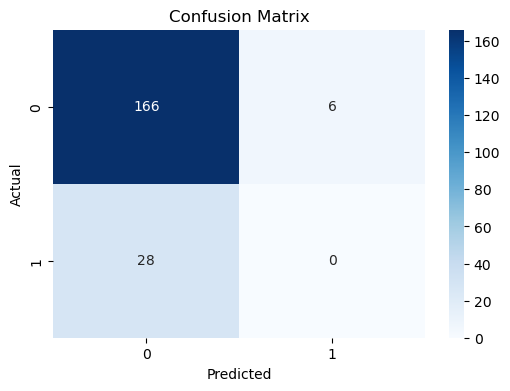

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()